## 1.1 安裝套件(若在colab訓練每次都需要執行)

In [74]:
!pip install fastbook -q
!pip install timm

## 1.2 讀取套件

In [2]:
from fastbook import *
from fastai.vision.widgets import *
import fastai
import timm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
print('fastai verison:', fastai.__version__)
print('torch version:', torch.__version__)

cuda:0
fastai verison: 2.8.7
torch version: 2.5.1+cu121



## 1.3 掛載Google雲端硬碟

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1.4 設定訓練資料路徑

* 若資料集是放在自己的雲端硬碟, 就設定成雲端硬碟路徑,
* 若是透過kaggle API下載, 檔案會存放在對應的資料夾中, ex: pcb_defects

In [3]:
path = Path('datasets/Human_Face_Emotions/')

# View all files in directory
path.ls()

[Path('datasets/Human_Face_Emotions/Angry'), Path('datasets/Human_Face_Emotions/Fear'), Path('datasets/Human_Face_Emotions/Happy'), Path('datasets/Human_Face_Emotions/Sad'), Path('datasets/Human_Face_Emotions/Suprise')]

### 1.4.1 清洗資料(可跳過)

In [ ]:
# 取得所有圖片
fns = get_image_files(path)

failed = verify_images(fns)
failed.map(Path.unlink) #unlink broken images

## 1.5 設定模型權重存檔路徑

In [4]:
#建立模型權重儲存路徑
modelPath='models/Human_Face_Emotions'
# !mkdir -p $modelPaths\
print(modelPath)

models/Human_Face_Emotions


## 2.1 資料讀取框架

## 2.3. 讀取圖檔結果

## 3.1. 選擇模型架構以及對應的預訓練權重

### 3.1.1 查詢所有可用的模型權重(可跳過)

In [8]:
timm.list_models()

['aimv2_1b_patch14_224',
 'aimv2_1b_patch14_336',
 'aimv2_1b_patch14_448',
 'aimv2_3b_patch14_224',
 'aimv2_3b_patch14_336',
 'aimv2_3b_patch14_448',
 'aimv2_huge_patch14_224',
 'aimv2_huge_patch14_336',
 'aimv2_huge_patch14_448',
 'aimv2_large_patch14_224',
 'aimv2_large_patch14_336',
 'aimv2_large_patch14_448',
 'bat_resnext26ts',
 'beit3_base_patch16_224',
 'beit3_giant_patch14_224',
 'beit3_giant_patch14_336',
 'beit3_large_patch16_224',
 'beit_base_patch16_224',
 'beit_base_patch16_384',
 'beit_large_patch16_224',
 'beit_large_patch16_384',
 'beit_large_patch16_512',
 'beitv2_base_patch16_224',
 'beitv2_large_patch16_224',
 'botnet26t_256',
 'botnet50ts_256',
 'caformer_b36',
 'caformer_m36',
 'caformer_s18',
 'caformer_s36',
 'cait_m36_384',
 'cait_m48_448',
 'cait_s24_224',
 'cait_s24_384',
 'cait_s36_384',
 'cait_xs24_384',
 'cait_xxs24_224',
 'cait_xxs24_384',
 'cait_xxs36_224',
 'cait_xxs36_384',
 'coat_lite_medium',
 'coat_lite_medium_384',
 'coat_lite_mini',
 'coat_lite_sma

### 3.1.2 查詢包含特定名稱的模型名稱(頭尾使用*代表任意字串, 中間的文字為需要包含的名稱)

In [9]:
timm.list_models('*dense*')

['densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'densenet264d',
 'densenetblur121d']

##  3.2 設定模型
* Note: metrics是模型訓練人員觀察的指標, 可設定多個

In [ ]:
dataset = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms= Resize(224),
    # 自訂義
    batch_tfms = [
        *aug_transforms(
            mult=1.2,
            flip_vert=False,
            max_rotate=15,
            max_zoom=1.1,
            max_lighting=0.2,
            max_warp=0.1
        ),
        Normalize.from_stats(*imagenet_stats)
        ]
  )

#利用框架正式讀取資料
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    bs=32
)

#讀取結果
print(f'此資料集共有{dls.c}種類別')
print(f'類別名稱為{dls.vocab}')
print(f'訓練資料有: {len(dls.train_ds)}筆, 驗證資料有: {len(dls.valid_ds)}筆')

此資料集共有5種類別
類別名稱為['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']
訓練資料有: 47278筆, 驗證資料有: 11819筆


訓練資料


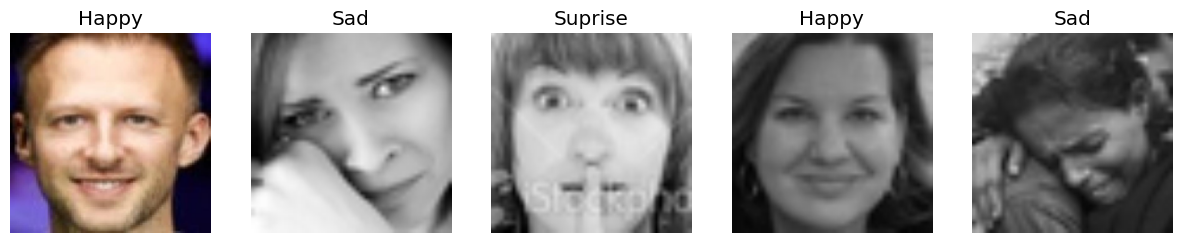

In [7]:
print('訓練資料')
dls.show_batch(max_n=5, nrows=1)

In [10]:
# learn = vision_learner(dls, models.resnet50, metrics=[accuracy, error_rate], pretrained=True)

# 自訂義
learn = vision_learner(
    dls,
    models.resnet50,
    pretrained=True,
    loss_func=LabelSmoothingCrossEntropy(),
    metrics=[accuracy, error_rate]
)

learn.to_fp16()

# learn.fine_tune(10)

In [ ]:
#查看模型架構, 可跳過
learn.summary()

## 3.3 訓練模型(Stage 1)

In [12]:
learn.fit_one_cycle(5, 1e-4)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.034532,1.591143,0.403841,0.596159,03:42
1,1.662462,1.391361,0.473560,0.526441,03:10
2,1.486662,1.392648,0.450884,0.549116,03:14
3,1.399218,1.343384,0.474744,0.525256,03:12
4,1.361220,1.290152,0.515610,0.484390,03:11


## 3.4 儲存第一次訓練好的權重

### 3.4.1 儲存要再次讀取的權重, 請使用save, 可不指定副檔名

In [13]:
learn.model_dir = "../../models"
learn.save("demo_stage-1")

Path('datasets/Human_Face_Emotions/../../models/demo_stage-1.pth')

### 3.4.2 輸出網頁用的權重請使用 export, 副檔名為.pkl

In [14]:
export_path = Path("../../models/demo_stage-1.pkl")
export_path.parent.mkdir(parents=True, exist_ok=True)

learn.export(export_path)

## 3.5 解凍權重再次訓練

### 3.5.1 使用unfreeze讓所有參數都可以被訓練

In [15]:
learn.unfreeze()

### 3.5.2 fastai有內建的函數可以提供learing rate的參考

<div></div>

Minimum/10: 6.31e-06, steepest point: 1.91e-06


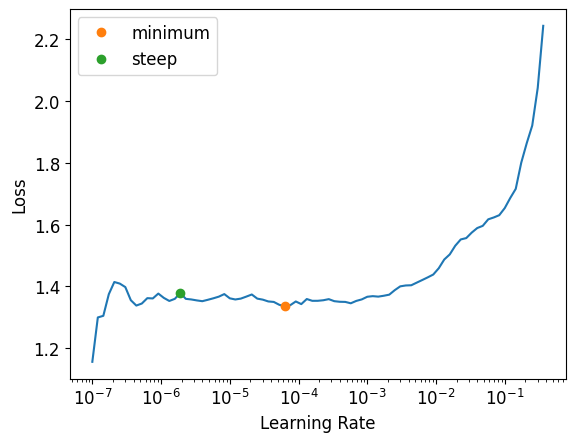

In [16]:
try:
    lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
    print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")
except Exception as e:
    print("lr_find 發生錯誤：")
    print(type(e).__name__)
    print(e)

### 3.5.3 進行第二次訓練

In [17]:
learn.fit_one_cycle(6, lr_max= 1e-4)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.213035,1.103637,0.627549,0.372451,03:32
1,0.975252,0.909291,0.741687,0.258313,03:32
2,0.739703,0.718498,0.849649,0.150351,03:33
3,0.541818,0.582571,0.928674,0.071326,03:32
4,0.469713,0.550040,0.936204,0.063796,03:35
5,0.442081,0.540212,0.936374,0.063626,03:31


## 3.6 儲存第二次訓練的權重

### 3.6.1 跟3.4相同, 根據需求使用不同的方法來儲存權重

In [18]:
learn.model_dir = "../../models"
learn.save("demo_stage-2")

Path('datasets/Human_Face_Emotions/../../models/demo_stage-2.pth')

In [19]:
export_path = Path("../../models/demo_stage-2.pkl")
export_path.parent.mkdir(parents=True, exist_ok=True)

learn.export(export_path)

<div></div>

Minimum/10: 7.59e-06, steepest point: 7.59e-07


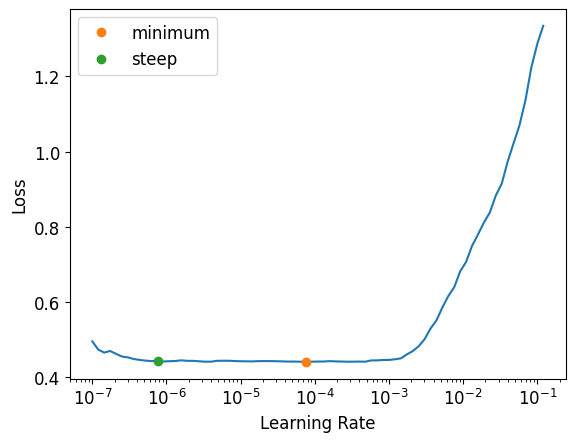

In [20]:
try:
    lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
    print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")
except Exception as e:
    print("lr_find 發生錯誤：")
    print(type(e).__name__)
    print(e)

In [21]:
learn.validate()

[0.5402124524116516, 0.9363736510276794, 0.06362636387348175]

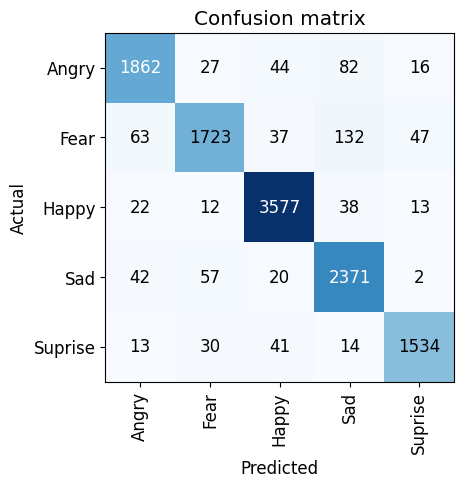

In [22]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

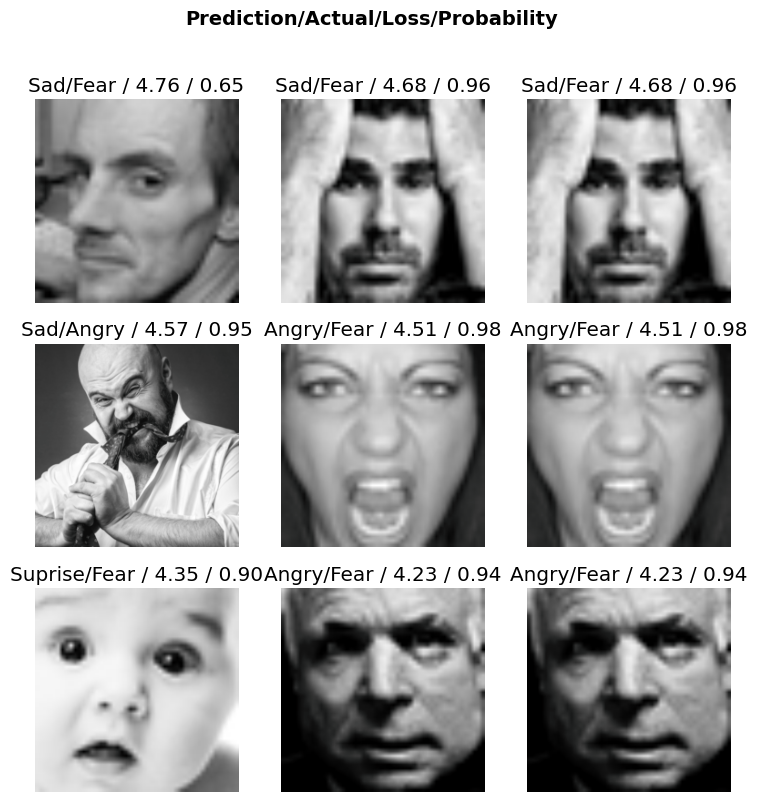

In [23]:
interp.plot_top_losses(9)

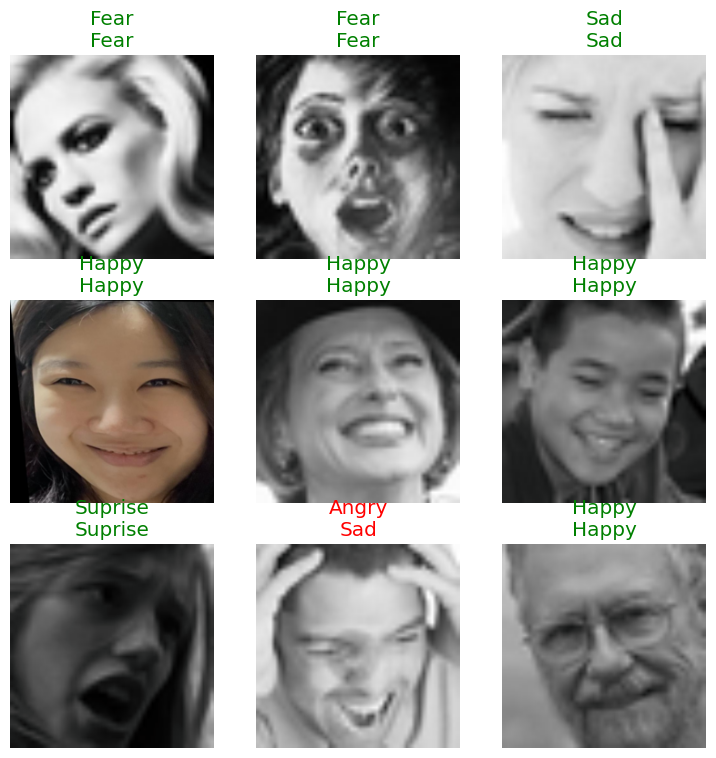

In [57]:
learn.show_results()

## 3.7 讀取之前訓練好的權重作為初始值, 再次進行訓練(option)

### 3.7.1 設定要讀取的權重路徑, 使用load方法進行讀取

In [34]:
myModel = './demo_stage-2'
learn.load(myModel)

### 3.7.2 再次訓練模型

In [36]:
# learn.fit_one_cycle(6, lr_max= 1e-5)

learn.fine_tune(3, base_lr=1e-4)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.422859,0.531190,0.937474,0.062526,03:26


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.425912,0.530615,0.939081,0.060919,03:37
1,0.421128,0.527432,0.938658,0.061342,03:31
2,0.422401,0.529447,0.937051,0.062949,03:41


### 3.7.3 儲存權重

In [37]:
learn.model_dir = "../../models"
learn.save("demo_stage-3")

Path('datasets/Human_Face_Emotions/../../models/demo_stage-3.pth')

### 3.7.4 輸出網頁用的權重

In [38]:
export_path = Path("../../models/demo_stage-3.pkl")
export_path.parent.mkdir(parents=True, exist_ok=True)

learn.export(export_path)

<div></div>

Minimum/10: 1.91e-07, steepest point: 7.59e-07


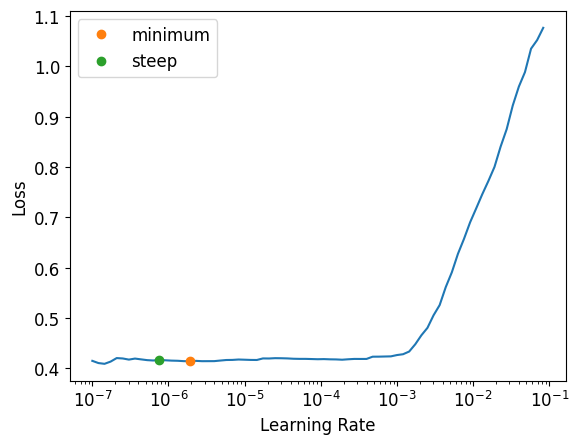

In [40]:
try:
    lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
    print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")
except Exception as e:
    print("lr_find 發生錯誤：")
    print(type(e).__name__)
    print(e)

In [39]:
learn.validate()

[0.5294474363327026, 0.9370505213737488, 0.06294948607683182]

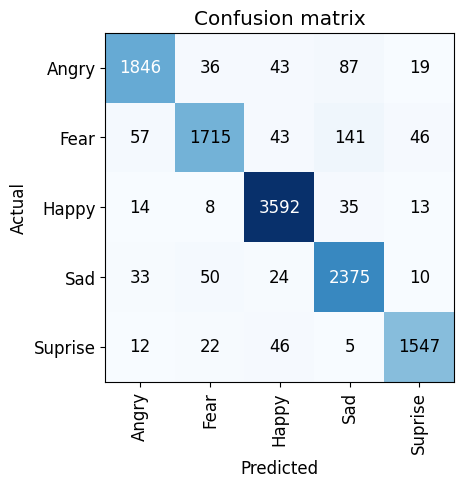

In [41]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

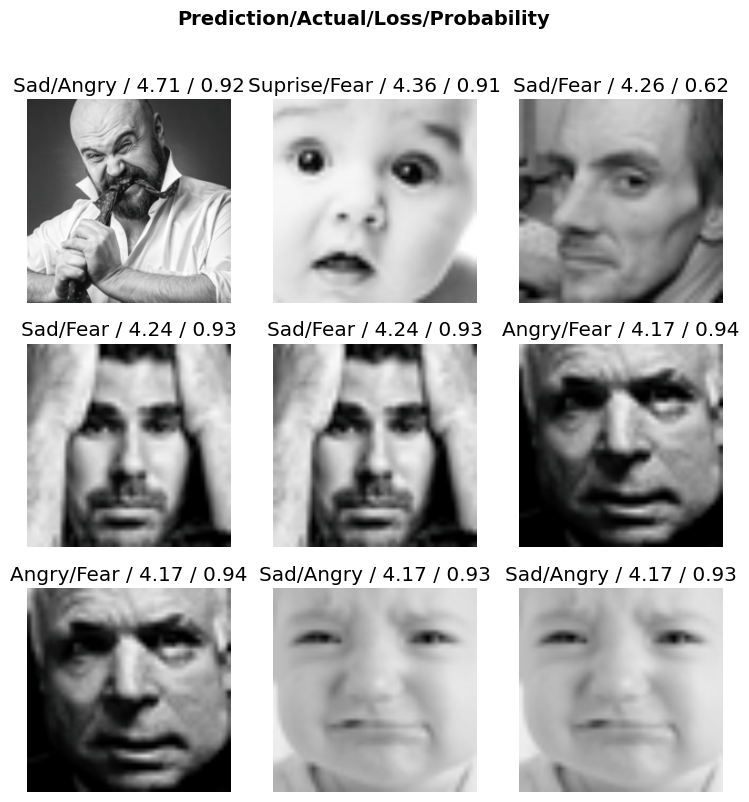

In [58]:
interp.plot_top_losses(9)

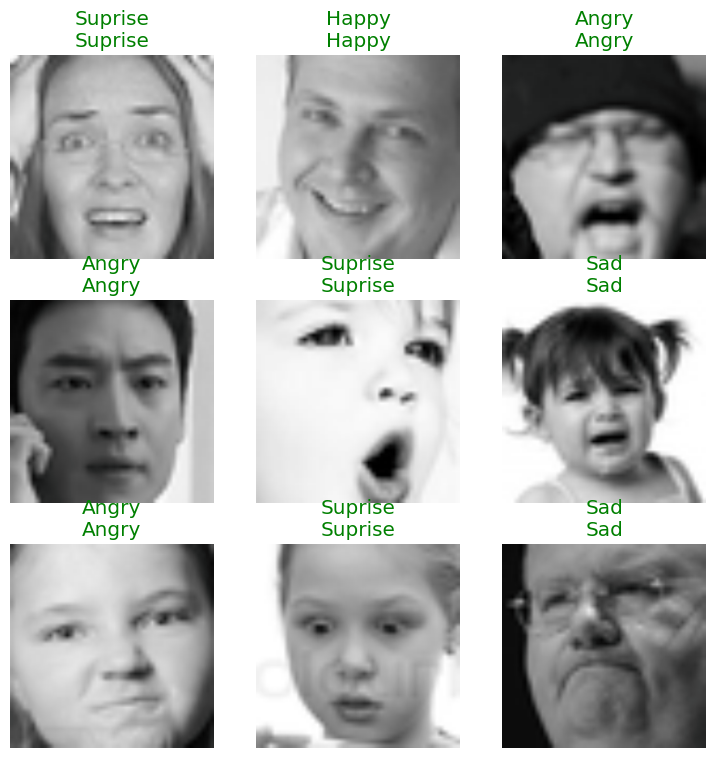

In [51]:
learn.show_results()

## 3.8 可反覆進行3.7的流程

## 4.1. 結果檢核(Confusion Matrix)

<div><progress max="739" value="0"></progress> 0.00% [0/739 00:00&lt;?]</div>

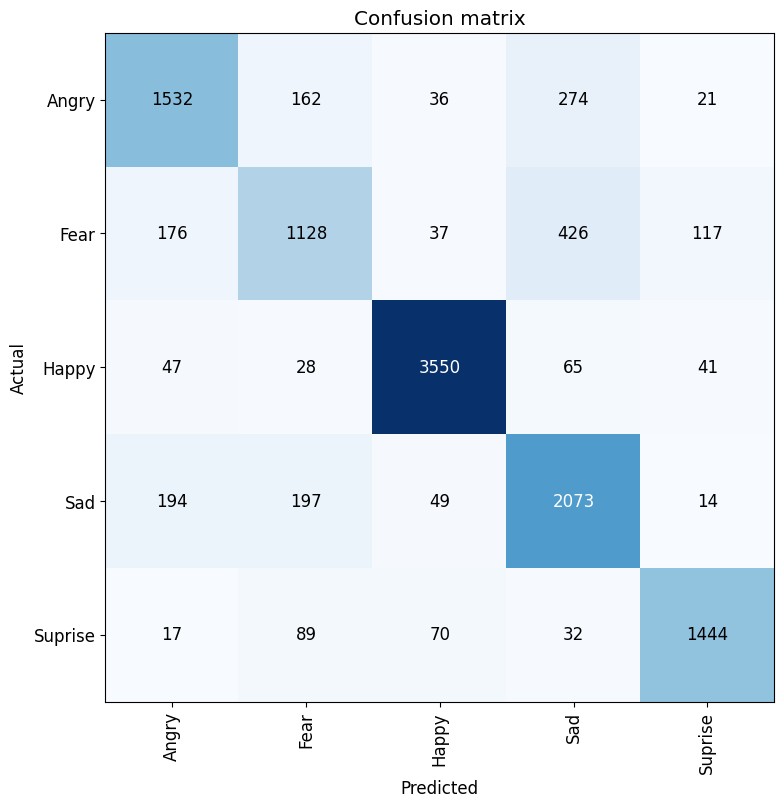

In [22]:
# Contains interpretation methods for classification models
interp = ClassificationInterpretation.from_learner(learn)

# Plot the confusion matrix
interp.plot_confusion_matrix(figsize=(8,8))

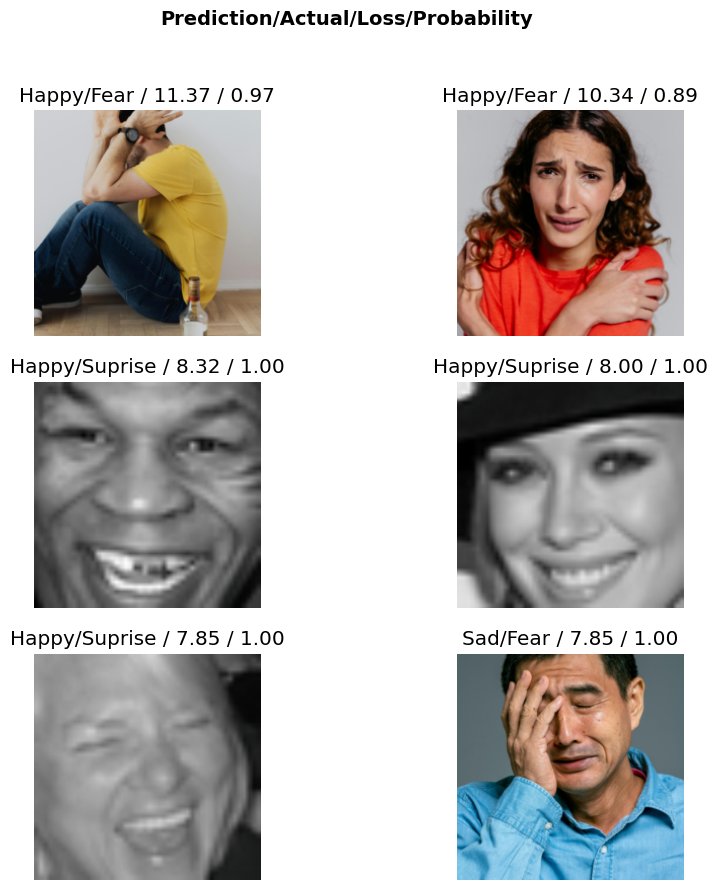

In [23]:
interp.plot_top_losses(6, nrows=3, figsize=(10,10))

## 4.2 ROC Curve and AUC

### 4.2.1 繪製所有類別的ROC Curve

In [52]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report

The accuracy is 93.71000000000001%.
              precision    recall  f1-score   support

       Angry     0.9409    0.9089    0.9246      2031
        Fear     0.9366    0.8566    0.8949      2002
       Happy     0.9584    0.9809    0.9695      3662
         Sad     0.8986    0.9530    0.9250      2492
     Suprise     0.9462    0.9479    0.9470      1632

    accuracy                         0.9371     11819
   macro avg     0.9361    0.9295    0.9322     11819
weighted avg     0.9374    0.9371    0.9367     11819



C:\Users\User\AppData\Local\Temp\ipykernel_34196\1026771491.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  probs = np.array(preds[:, i])
C:\Users\User\AppData\Local\Temp\ipykernel_34196\1026771491.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  probs = np.array(preds[:, i])
C:\Users\User\AppData\Local\Temp\ipykernel_34196\1026771491.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must impl

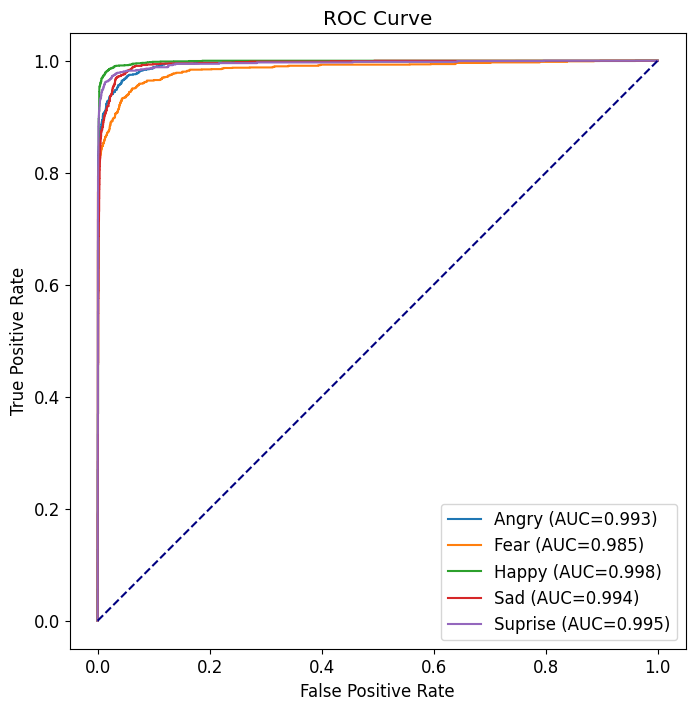

In [53]:
preds, y, loss = learn.get_preds(with_loss=True)
# get accuracy
acc = accuracy(preds, y)
print('The accuracy is {0}%.'.format( 100* round( float(acc), 4) ) )

class_num = dls.c
class_name = dls.vocab

pred_class = preds.argmax(axis=1)
print(classification_report(y, pred_class, target_names=class_name, digits=4))

plt.figure(figsize=(8, 8))
for i in range(class_num) :
    probs = np.array(preds[:, i])
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y, probs, pos_label=i)
    # Compute ROC area
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label='{0} (AUC={1})'.format( class_name[i], round(roc_auc, 3) ) )

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.axis('square')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")


### 4.2.2 只繪製特定類別的ROC Curve與計算AUC

In [54]:
#手動修改要計算的類別id
targe_class = 1

The accuracy is 93.71000000000001%.
Area under the curve of ROC in class Fear is 0.9850695296350793


C:\Users\User\AppData\Local\Temp\ipykernel_34196\2965202172.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  probs = np.array(preds[:,targe_class])


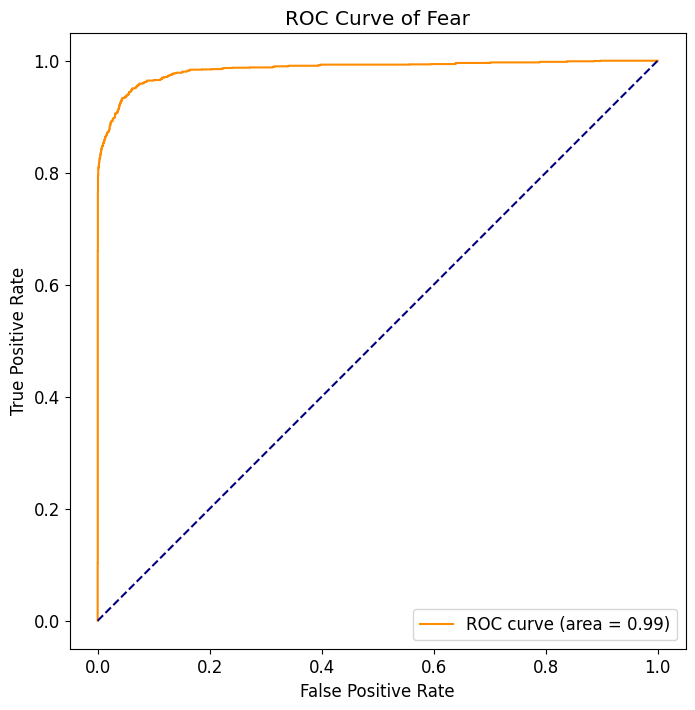

In [55]:
preds, y, loss = learn.get_preds(with_loss=True)
# get accuracy
acc = accuracy(preds, y)
print('The accuracy is {0}%.'.format( 100* round( float(acc), 4) ) )

probs = np.array(preds[:,targe_class])

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, probs, pos_label=targe_class)

# Compute ROC area
roc_auc = auc(fpr, tpr)
print('Area under the curve of ROC in class {0} is {1}'.format( dls.vocab[targe_class], roc_auc))

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.axis('square')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of {0}'.format(dls.vocab[targe_class]))
plt.legend(loc="lower right")